In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt
from IPython.display import Video
from scipy.spatial.transform import Rotation

from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
import seaborn as sb
import itertools


import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#plt.style.use("seaborn-deep")

sb.set_palette("husl",3)
sb.set_style("whitegrid")

# Manual selection of classes from folders
# !!! For automatic processing all classes go to "Automatic" 

### Function to load data from single folder

In [2]:
def load_and_label_data(file_paths, label):
    """Load data from multiple CSV files and assign a label."""
    data_list = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        # The CSV contains 'ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3'
        df['label'] = label
        data_list.append(df)
    return pd.concat(data_list)

### Load side_raise data

In [3]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/front_raise/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))


34


In [4]:
completedf_side_raise = load_and_label_data(excersise_files, 'side_raise')

In [5]:
completedf_side_raise

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,4175698,4201.0,-2552.0,4161.0,0.837,0.198,-0.174,0.479,side_raise
1,4175724,5033.0,-2700.0,4315.0,0.839,0.186,-0.205,0.468,side_raise
2,4175740,10853.0,-6938.0,8529.0,0.842,0.173,-0.223,0.460,side_raise
3,4175756,7279.0,-4268.0,9501.0,0.844,0.158,-0.233,0.456,side_raise
4,4175772,4305.0,-3212.0,10185.0,0.847,0.145,-0.240,0.452,side_raise
...,...,...,...,...,...,...,...,...,...
844,730969,7714.0,3592.0,556.0,0.451,0.691,-0.278,0.492,side_raise
845,730985,7264.0,3704.0,772.0,0.448,0.691,-0.276,0.495,side_raise
846,731001,7326.0,3376.0,644.0,0.447,0.692,-0.274,0.497,side_raise
847,731017,7702.0,3054.0,88.0,0.446,0.692,-0.272,0.498,side_raise


### Load shoulder_press data

In [6]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/shoulder_press/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

114


In [7]:
completedf_shoulder_press = load_and_label_data(excersise_files, 'shoulder_press')

In [8]:
completedf_shoulder_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,359849,-2411.0,-2335.0,-96.0,0.621,-0.501,0.483,0.360,shoulder_press
1,359865,-2529.0,-2209.0,302.0,0.620,-0.502,0.483,0.362,shoulder_press
2,359884,-3037.0,-2081.0,538.0,0.618,-0.505,0.481,0.362,shoulder_press
3,359900,-2829.0,-2329.0,426.0,0.617,-0.508,0.480,0.361,shoulder_press
4,359916,-2679.0,-1649.0,490.0,0.616,-0.513,0.478,0.358,shoulder_press
...,...,...,...,...,...,...,...,...,...
1096,2044427,-5300.0,2470.0,523.0,0.599,0.641,0.258,-0.403,shoulder_press
1097,2044445,-5060.0,6294.0,-165.0,0.600,0.649,0.242,-0.400,shoulder_press
1098,2044463,-7382.0,8172.0,-675.0,0.606,0.653,0.227,-0.393,shoulder_press
1099,2044481,-5510.0,7266.0,381.0,0.615,0.656,0.208,-0.385,shoulder_press


## Load rope tricep pushdown

In [6]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/rope_tricep_pushdown/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

66


In [7]:
completedf_rope_tricep_pushdown = load_and_label_data(excersise_files, 'rope_tricep_pushdown')

In [8]:
completedf_rope_tricep_pushdown

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,22194,-2050.0,1180.0,-412.0,0.651,0.511,0.481,0.289,rope_tricep_pushdown
1,22220,-2336.0,2158.0,-60.0,0.646,0.519,0.479,0.289,rope_tricep_pushdown
2,22236,-1896.0,2458.0,174.0,0.641,0.528,0.474,0.292,rope_tricep_pushdown
3,22252,-1526.0,2484.0,328.0,0.635,0.537,0.468,0.298,rope_tricep_pushdown
4,22268,-1344.0,3504.0,726.0,0.629,0.546,0.461,0.305,rope_tricep_pushdown
...,...,...,...,...,...,...,...,...,...
777,855680,-2692.0,6438.0,1580.0,0.077,-0.099,0.666,0.735,rope_tricep_pushdown
778,855697,-2728.0,6666.0,1500.0,0.085,-0.107,0.669,0.731,rope_tricep_pushdown
779,855713,-2604.0,7022.0,1234.0,0.093,-0.116,0.671,0.726,rope_tricep_pushdown
780,855729,-2938.0,7128.0,992.0,0.101,-0.124,0.673,0.722,rope_tricep_pushdown


### Load curl data

In [9]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/curl/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

81


In [10]:
completedf_curl = load_and_label_data(excersise_files, 'curl')

In [11]:
completedf_curl

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,667522,7970.0,-930.0,886.0,0.685,0.149,-0.658,0.277,curl
1,667539,8152.0,-1186.0,920.0,0.684,0.149,-0.658,0.278,curl
2,667565,8012.0,-1054.0,804.0,0.683,0.148,-0.658,0.279,curl
3,667581,7852.0,-1304.0,744.0,0.683,0.148,-0.658,0.280,curl
4,667597,7828.0,-1568.0,828.0,0.684,0.148,-0.657,0.281,curl
...,...,...,...,...,...,...,...,...,...
1047,6448388,7997.0,5335.0,-461.0,0.017,-0.676,-0.121,-0.727,curl
1048,6448405,7939.0,5579.0,-395.0,0.013,-0.676,-0.118,-0.727,curl
1049,6448422,7571.0,4633.0,-33.0,0.008,-0.677,-0.116,-0.727,curl
1050,6448439,7765.0,4723.0,-373.0,0.001,-0.678,-0.116,-0.726,curl


### Load non_exercise data

In [12]:
PATH_TO_EXERCISE_FOLDER = "../data/cleaned/non_exersice/"

non_excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(non_excersise_files))

378


In [13]:
completedf_non_exersice = load_and_label_data(non_excersise_files, 'non_exersice')

C:\Users\emder\AppData\Local\Temp\ipykernel_3796\350646870.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(data_list)


In [14]:
completedf_non_exersice

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,1319018,-2552.0,7677.0,1652.0,0.082,-0.102,0.637,0.759,non_exersice
1,1319034,-2500.0,7793.0,1812.0,0.083,-0.104,0.634,0.762,non_exersice
2,1319050,-2360.0,7907.0,1656.0,0.083,-0.105,0.629,0.766,non_exersice
3,1319067,-2422.0,7761.0,1876.0,0.083,-0.107,0.624,0.770,non_exersice
4,1319084,-2660.0,7243.0,2252.0,0.083,-0.109,0.617,0.775,non_exersice
...,...,...,...,...,...,...,...,...,...
843,4175617,1161.0,-1132.0,3283.0,0.793,0.215,-0.040,0.569,non_exersice
844,4175633,1991.0,-1078.0,3789.0,0.807,0.216,-0.062,0.546,non_exersice
845,4175649,2987.0,-724.0,3839.0,0.818,0.218,-0.086,0.525,non_exersice
846,4175665,3931.0,-902.0,3891.0,0.827,0.215,-0.113,0.507,non_exersice


### Concatenate into one dataframe

In [15]:
#df_concatenated = pd.concat([completedf_barbell_bench_press, completedf_shoulder_press, completedf_curl, completedf_non_exersice_press], ignore_index=True)
#df_concatenated = pd.concat([completedf_non_exersice, completedf_curl, completedf_side_raise], ignore_index=True)

# works well
#df_concatenated = pd.concat([completedf_non_exersice, completedf_curl, completedf_side_raise], ignore_index=True)

df_concatenated = pd.concat([completedf_non_exersice, completedf_curl, completedf_side_raise, completedf_rope_tricep_pushdown], ignore_index=True)

In [16]:
df_concatenated

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,1319018,-2552.0,7677.0,1652.0,0.082,-0.102,0.637,0.759,non_exersice
1,1319034,-2500.0,7793.0,1812.0,0.083,-0.104,0.634,0.762,non_exersice
2,1319050,-2360.0,7907.0,1656.0,0.083,-0.105,0.629,0.766,non_exersice
3,1319067,-2422.0,7761.0,1876.0,0.083,-0.107,0.624,0.770,non_exersice
4,1319084,-2660.0,7243.0,2252.0,0.083,-0.109,0.617,0.775,non_exersice
...,...,...,...,...,...,...,...,...,...
484275,855680,-2692.0,6438.0,1580.0,0.077,-0.099,0.666,0.735,rope_tricep_pushdown
484276,855697,-2728.0,6666.0,1500.0,0.085,-0.107,0.669,0.731,rope_tricep_pushdown
484277,855713,-2604.0,7022.0,1234.0,0.093,-0.116,0.671,0.726,rope_tricep_pushdown
484278,855729,-2938.0,7128.0,992.0,0.101,-0.124,0.673,0.722,rope_tricep_pushdown


# Automatic dataset processing (skip if need Manual selection)

## Load all data in loop

In [40]:
def load_all_data(base_folder):
    """
    Load and label data from all exercise folders within a base folder.
    
    Parameters:
    - base_folder: The path to the base folder containing exercise subfolders.
    
    Returns:
    - A pandas DataFrame containing all data, labeled by exercise.
    """
    all_data_frames = []
    # List all subdirectories in the base folder
    for folder_name in os.listdir(base_folder):
        folder_path = os.path.join(base_folder, folder_name)
        if os.path.isdir(folder_path):
            exercise_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
            # Use the folder name as the label
            df_labeled = load_and_label_data(exercise_files, folder_name)
            all_data_frames.append(df_labeled)
    
    # Concatenate all DataFrames, ignoring index to reset it in the final DataFrame
    df_concatenated = pd.concat(all_data_frames, ignore_index=True)
    return df_concatenated

In [41]:
BASE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/"

df_concatenated = load_all_data(BASE_FOLDER)

# Training section
df_concatenated is dataframe build during Manual or Automatic data preparation stages.

Data shape before augmentation

In [17]:
df_concatenated.shape

(477510, 9)

In [18]:
unique_classes = df_concatenated['label'].unique()
print(unique_classes.shape)

(4,)


In [19]:
unique_classes_counts = df_concatenated['label'].value_counts()
print(unique_classes_counts)

label
non_exersice      250773
curl              129853
shoulder_press    107236
front_raise        57395
Name: count, dtype: int64


### Split into X, Y

In [40]:
def split_sequences(dataframe, sequence_length, overlap=0):
    """
    Split the dataframe into sequences of a given length with a specified overlap, including all relevant columns.

    :param dataframe: Input dataframe to be split into sequences.
    :param sequence_length: The length of each sequence.
    :param overlap: The number of rows that will overlap between consecutive sequences.
    :return: A tuple of numpy arrays, (X, y), where X is the sequence of features and y is the corresponding label.
    """
    X, y = [], []
    # columns_of_interest = ['q0', 'q1', 'q2', 'q3']
    columns_of_interest = ['ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3']
    
    # Ensure overlap is not larger than sequence_length
    overlap = min(overlap, sequence_length - 1)
    
    # Calculate step size based on sequence_length and overlap
    step_size = sequence_length - overlap
    
    for i in range(0, len(dataframe) - sequence_length + 1, step_size):
        sequence = dataframe.iloc[i:i+sequence_length][columns_of_interest]
        label = dataframe.iloc[i]['label']
        X.append(sequence.values)
        y.append(label)
    
    return np.array(X), np.array(y)

In [41]:
sample_length = 500
#overlap_length = 125
#x, y = split_sequences(df_concatenated, sample_length, overlap_length)
x, y = split_sequences(df_concatenated, sample_length)

In [42]:
len(x), len(y)

(968, 968)

## Check number of samples per class 

In [43]:
from collections import Counter
samples_per_class = Counter(y)
print(samples_per_class)

Counter({'non_exersice': 635, 'curl': 180, 'rope_tricep_pushdown': 91, 'side_raise': 62})


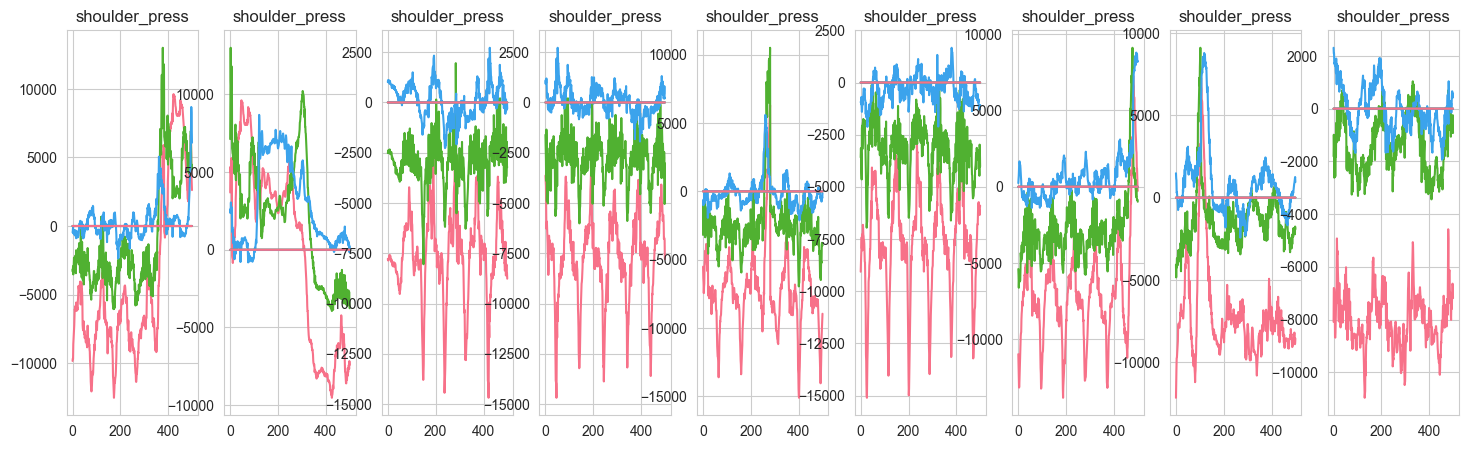

In [44]:
start_id = 300
plt.figure(figsize=(20, 5))
for i in range(1, 10):
    plt.subplot(1, 10, i)
    plt.plot(x[start_id+i])
    plt.title(y[start_id+i])
plt.show()

## Model Train

### Split into train, test, val set

In [45]:
X_train_val, X_val, y_train_val, y_val = train_test_split(x, y, test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X_train_val, y_train_val, test_size=0.2)

In [46]:
len(np.unique(y_train))

4

In [47]:
len(np.unique(y_test))

4

In [48]:
y_train.shape, X_train.shape

((929,), (929, 500, 7))

In [49]:
y_test.shape, X_test.shape

((233,), (233, 500, 7))

In [50]:
y_val.shape, X_val.shape

((291,), (291, 500, 7))

### Convert to one hot encoding

In [51]:
class_names = np.unique(y_train)
num_classes = len(np.unique(y_train))
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert text labels into numeric identifiers
y_train_encoded = label_encoder.fit_transform(y_train)

# Convert numeric labels into one-hot
y_train_one_hot = to_categorical(y_train_encoded)


# Convert text labels into numeric identifiers
y_val_encoded = label_encoder.fit_transform(y_val)


# Convert numeric labels into one-hot
y_val_one_hot = to_categorical(y_val_encoded)

# Convert text labels into numeric identifiers
y_test_encoded = label_encoder.fit_transform(y_test)

# Convert numeric labels into one-hot
y_test_one_hot = to_categorical(y_test_encoded)

# To be used in inference script. Here print correspondence between class name and ID

In [52]:
mapping = dict(zip(label_encoder.classes_, range(0, len(label_encoder.classes_)+1)))
print(mapping)


{'curl': 0, 'front_raise': 1, 'non_exersice': 2, 'shoulder_press': 3}


## Debug input for inference testing

In [53]:
np.set_printoptions(threshold=np.inf, linewidth=700)
#X_test[0]
#np.save('model_input.npy', X_test[0])

### Define model

In [56]:
# Define the model
inputs = tf.keras.Input(shape=(sample_length, 7))

# Apply Dense layers to the inputs
layer = keras.layers.Dense(256, activation=tf.nn.relu6)(inputs)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(128, activation=tf.nn.relu6)(layer)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(64, activation=tf.nn.relu6)(layer)
layer = keras.layers.Dropout(0.5)(layer)
# Add GlobalAveragePooling1D to reduce dimensionality
layer = keras.layers.GlobalAveragePooling1D()(layer)

# Final layer for classification
outputs = keras.layers.Dense(len(np.unique(y_train)), activation="softmax")(layer)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 500, 7)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 500, 128)            │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 500, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 500, 64)             │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 500, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,540 (37.27 KB)

 Trainable params: 9,540 (37.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [57]:
adamopt = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8)

model.compile(
    optimizer=adamopt,#"adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
checkpoint_path = "weights.best.hdf5"
checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', 
                                              patience=50)

# Start training
print(X_train.shape)
history = model.fit(X_train, y_train_one_hot,
                    epochs=200,
                    batch_size=16,
                    validation_data=(X_val, y_val_one_hot),
                    callbacks=[checkpoint, earlystopping],
                    )

Filepath provided did not end in '.keras'. Continuing anyways...
(929, 500, 7)
Epoch 1/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6270 - loss: 1.1085
Epoch 1: val_accuracy improved from -inf to 0.87629, saving model to weights.best.hdf5


59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6318 - loss: 1.0950 - val_accuracy: 0.8763 - val_loss: 0.4977
Epoch 2/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8917 - loss: 0.3957
Epoch 2: val_accuracy improved from 0.87629 to 0.89003, saving model to weights.best.hdf5


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8919 - loss: 0.3967 - val_accuracy: 0.8900 - val_loss: 0.3434
Epoch 3/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8577 - loss: 0.4003
Epoch 3: val_accuracy did not improve from 0.89003
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8588 - loss: 0.3985 - val_accuracy: 0.8900 - val_loss: 0.2843
Epoch 4/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9259 - loss: 0.2698
Epoch 4: val_accuracy improved from 0.89003 to 0.90034, saving model to weights.best.hdf5


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9256 - loss: 0.2699 - val_accuracy: 0.9003 - val_loss: 0.2934
Epoch 5/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9019 - loss: 0.2943
Epoch 5: val_accuracy improved from 0.90034 to 0.91753, saving model to weights.best.hdf5


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9022 - loss: 0.2934 - val_accuracy: 0.9175 - val_loss: 0.2684
Epoch 6/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9399 - loss: 0.2402
Epoch 6: val_accuracy did not improve from 0.91753
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9393 - loss: 0.2407 - val_accuracy: 0.9072 - val_loss: 0.2695
Epoch 7/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9203 - loss: 0.2815
Epoch 7: val_accuracy did not improve from 0.91753
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9203 - loss: 0.2812 - val_accuracy: 0.9175 - val_loss: 0.3100
Epoch 8/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9241 - loss: 0.2692
Epoch 8: val_accuracy did not improve from 0.91753
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9241 - loss: 0.2690 - val_accuracy: 0.9175 - val_loss: 0.3250
Epoch 9/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9151 - loss: 0.2524
Epoch 9: val_accuracy did not improve from 

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9223 - loss: 0.2437 - val_accuracy: 0.9210 - val_loss: 0.2780
Epoch 11/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9284 - loss: 0.2454
Epoch 11: val_accuracy did not improve from 0.92096
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9288 - loss: 0.2439 - val_accuracy: 0.9141 - val_loss: 0.2595
Epoch 12/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9393 - loss: 0.1938
Epoch 12: val_accuracy did not improve from 0.92096
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9392 - loss: 0.1942 - val_accuracy: 0.9141 - val_loss: 0.2566
Epoch 13/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9176 - loss: 0.2278
Epoch 13: val_accuracy did not improve from 0.92096
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9180 - loss: 0.2274 - val_accuracy: 0.8969 - val_loss: 0.3635
Epoch 14/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9398 - loss: 0.1902
Epoch 14: val_accuracy did not impro

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9208 - loss: 0.2344 - val_accuracy: 0.9278 - val_loss: 0.2753
Epoch 23/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9200 - loss: 0.2256
Epoch 23: val_accuracy did not improve from 0.92784
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9206 - loss: 0.2247 - val_accuracy: 0.9175 - val_loss: 0.2378
Epoch 24/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9294 - loss: 0.2298
Epoch 24: val_accuracy did not improve from 0.92784
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9292 - loss: 0.2296 - val_accuracy: 0.9072 - val_loss: 0.2992
Epoch 25/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9507 - loss: 0.1684
Epoch 25: val_accuracy did not improve from 0.92784
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9498 - loss: 0.1698 - val_accuracy: 0.9210 - val_loss: 0.2715
Epoch 26/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9471 - loss: 0.1721
Epoch 26: val_accuracy did not impro

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9408 - loss: 0.1749 - val_accuracy: 0.9347 - val_loss: 0.2217
Epoch 36/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9529 - loss: 0.1442
Epoch 36: val_accuracy did not improve from 0.93471
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9520 - loss: 0.1455 - val_accuracy: 0.9210 - val_loss: 0.2550
Epoch 37/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9426 - loss: 0.1679
Epoch 37: val_accuracy did not improve from 0.93471
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9425 - loss: 0.1691 - val_accuracy: 0.9141 - val_loss: 0.2412
Epoch 38/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9166 - loss: 0.2616
Epoch 38: val_accuracy did not improve from 0.93471
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9168 - loss: 0.2606 - val_accuracy: 0.9244 - val_loss: 0.2541
Epoch 39/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9513 - loss: 0.1589
Epoch 39: val_accuracy did not impro

### Plot graph

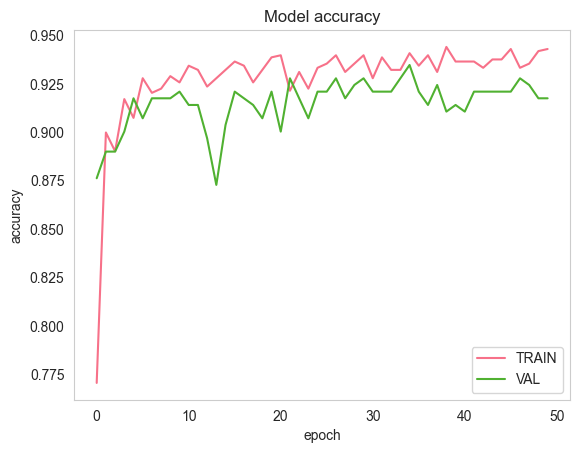

In [58]:
# Visualize the training history to see whether you're overfitting.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')
plt.grid()
plt.show()

### Plot confusion matrix

In [59]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9547 - loss: 0.1800


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Confusion matrix, without normalization

Classification Report:
                 precision    recall  f1-score   support

          curl       0.93      0.93      0.93        59
   front_raise       0.96      0.96      0.96        25
  non_exersice       0.96      0.96      0.96       114
shoulder_press       0.97      0.97      0.97        35

      accuracy                           0.95       233
     macro avg       0.95      0.95      0.95       233
  weighted avg       0.95      0.95      0.95       233



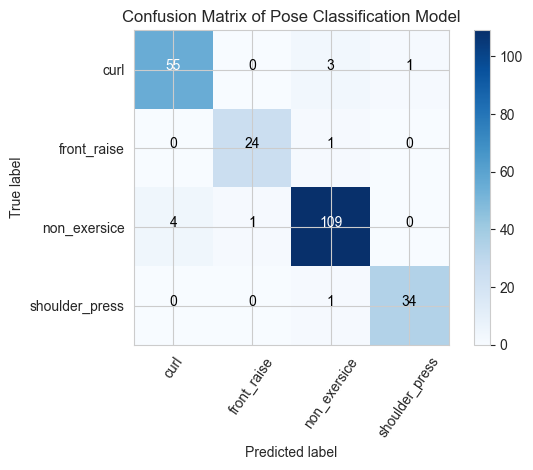

In [60]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

# Classify pose in the TEST dataset using the trained model
y_pred = model.predict(X_test)

# Convert the prediction result to class name
y_pred_label = [class_names[i] for i in np.argmax(y_pred, axis=1)]
y_true_label = [class_names[i] for i in np.argmax(y_test_one_hot, axis=1)]

# Plot the confusion matrix
cm = confusion_matrix(np.argmax(y_test_one_hot, axis=1), np.argmax(y_pred, axis=1))
plot_confusion_matrix(cm,
                      class_names,
                      title ='Confusion Matrix of Pose Classification Model')

# Print the classification report
print('\nClassification Report:\n', classification_report(y_true_label, y_pred_label))